In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Visualization settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [21]:
file_path = "supermarket_sales.csv"
df = pd.read_csv(file_path)
# Preview dataset
print("First 5 rows of dataset:")
print(df.head())
print("\nDataset Shape:", df.shape)

First 5 rows of dataset:
  Invoice_ID Branch       City Customer_Type  Gender         Product_Line  \
0  INV000001      B   Mandalay        Member    Male     Food & Beverages   
1  INV000002      C   Mandalay        Member  Female     Food & Beverages   
2  INV000003      C  Naypyitaw        Normal  Female  Fashion Accessories   
3  INV000004      B  Naypyitaw        Member  Female     Food & Beverages   
4  INV000005      C     Yangon        Normal  Female     Food & Beverages   

   Unit_Price  Quantity   Tax   Total        Date   Time      Payment  Rating  
0       69.36         3  7.28  119.58  2023-08-08  18:54  Credit card     8.4  
1       35.25         1  6.62  137.13  2023-02-09  18:44  Credit card     4.3  
2       57.56         8  4.66  490.48  2023-08-24  16:16         Cash     9.6  
3       16.60         5  8.57  142.54  2023-02-09  11:35         Cash     4.5  
4       49.07         1  3.70   24.43  2023-07-04   8:56  Credit card     5.8  

Dataset Shape: (2000, 14)


In [22]:
print("\nColumn Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())



Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice_ID     2000 non-null   object 
 1   Branch         2000 non-null   object 
 2   City           2000 non-null   object 
 3   Customer_Type  2000 non-null   object 
 4   Gender         2000 non-null   object 
 5   Product_Line   2000 non-null   object 
 6   Unit_Price     2000 non-null   float64
 7   Quantity       2000 non-null   int64  
 8   Tax            2000 non-null   float64
 9   Total          2000 non-null   float64
 10  Date           2000 non-null   object 
 11  Time           2000 non-null   object 
 12  Payment        2000 non-null   object 
 13  Rating         2000 non-null   float64
dtypes: float64(4), int64(1), object(9)
memory usage: 218.9+ KB
None

Statistical Summary:
        Unit_Price   Quantity          Tax        Total       Rating
count  2

In [23]:
print("\nMissing Values:")
print(df.isnull().sum()) 
# Drop rows if critical values missing
df = df.dropna()
# Confirm cleaning
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values:
Invoice_ID       0
Branch           0
City             0
Customer_Type    0
Gender           0
Product_Line     0
Unit_Price       0
Quantity         0
Tax              0
Total            0
Date             0
Time             0
Payment          0
Rating           0
dtype: int64

Missing Values After Cleaning:
Invoice_ID       0
Branch           0
City             0
Customer_Type    0
Gender           0
Product_Line     0
Unit_Price       0
Quantity         0
Tax              0
Total            0
Date             0
Time             0
Payment          0
Rating           0
dtype: int64


In [24]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])
# Create new columns
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

In [25]:
# 6. DAILY SALES TREND
daily_sales = df.groupby("Date")["Total"].sum().reset_index()
print(daily_sales.head())

        Date    Total
0 2023-01-01  1145.28
1 2023-01-02  1631.56
2 2023-01-03   775.06
3 2023-01-04  1285.96
4 2023-01-05   176.61


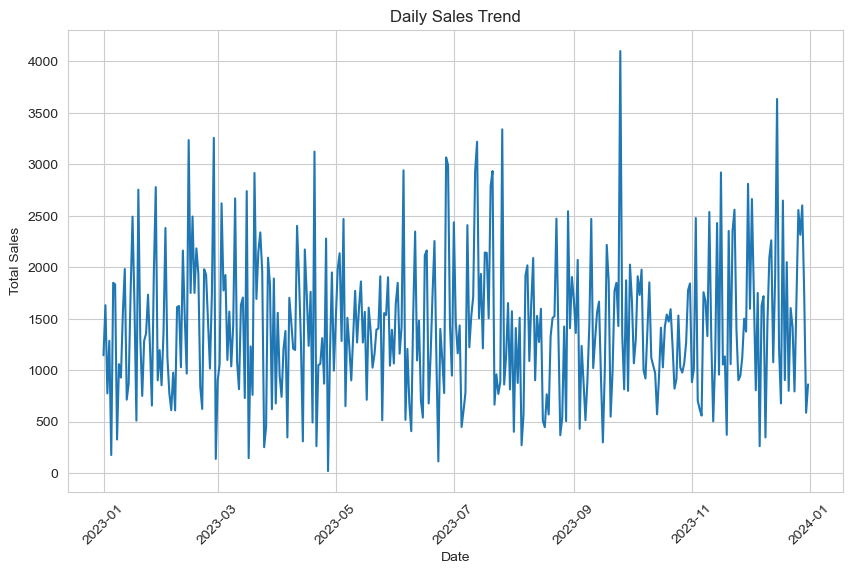

In [26]:
plt.figure()
sns.lineplot(data=daily_sales, x="Date", y="Total")
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [31]:
top_products = df.groupby("Product_Line")["Total"].sum().sort_values(ascending=False)

print("\nTop Selling Products:")
print(top_products)


Top Selling Products:
Product_Line
Health & Beauty           96970.32
Sports & Travel           91177.89
Electronic Accessories    88995.19
Home & Lifestyle          86351.63
Food & Beverages          78233.94
Fashion Accessories       77551.72
Name: Total, dtype: float64


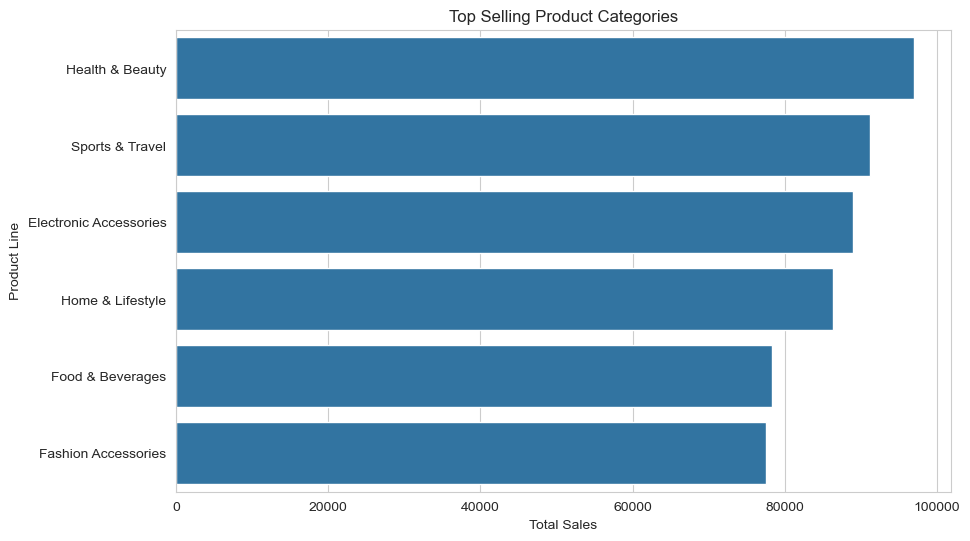

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top Selling Product Categories")
plt.xlabel("Total Sales")
plt.ylabel("Product Line")

plt.show()

Product_Line
Electronic Accessories    88995.19
Fashion Accessories       77551.72
Food & Beverages          78233.94
Health & Beauty           96970.32
Home & Lifestyle          86351.63
Sports & Travel           91177.89
Name: Total, dtype: float64


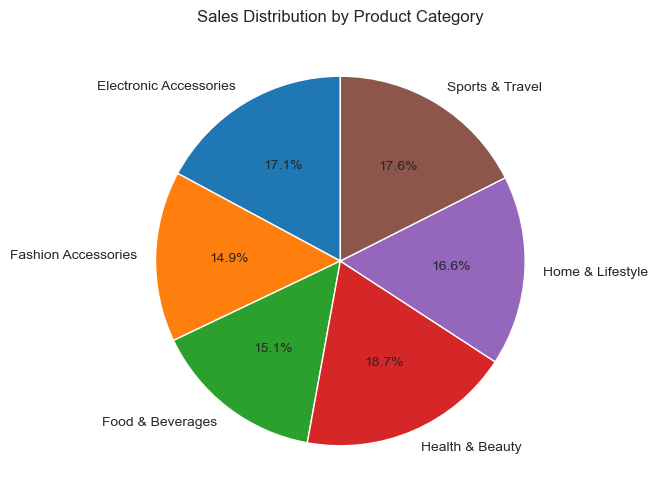

In [34]:
# 8. SALES BY CATEGORY
category_sales = df.groupby("Product_Line")["Total"].sum()
print(category_sales)
# Visualization – Category Sales
import matplotlib.pyplot as plt
plt.figure()
category_sales.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Sales Distribution by Product Category")
plt.ylabel("")
plt.show()

Branch
A    179047.93
B    180821.79
C    159410.97
Name: Total, dtype: float64


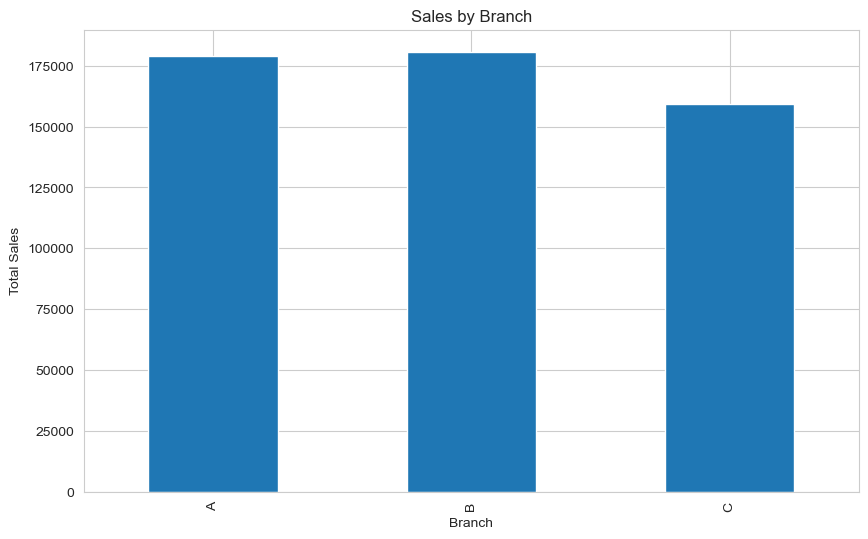

In [35]:
# 9. SALES BY BRANCH
branch_sales = df.groupby("Branch")["Total"].sum()
print(branch_sales)
plt.figure()
branch_sales.plot(kind="bar")
plt.title("Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Sales")
plt.show()

In [36]:
# 10. KEY INSIGHTS
print("Key Insights")
print("1. Total Revenue:", df["Total"].sum())
print("2. Average Transaction Value:", df["Total"].mean())
print("3. Best Selling Category:")
print(df.groupby("Product_Line")["Total"].sum().idxmax())
print("4. Best Performing Branch:")
print(df.groupby("Branch")["Total"].sum().idxmax())

Key Insights
1. Total Revenue: 519280.69
2. Average Transaction Value: 259.640345
3. Best Selling Category:
Health & Beauty
4. Best Performing Branch:
B


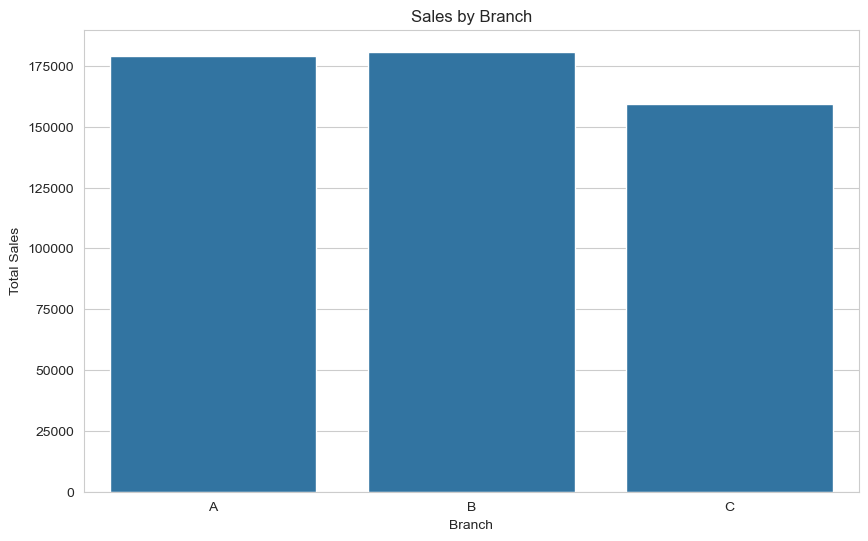

In [37]:
import seaborn as sns

plt.figure()
sns.barplot(x=branch_sales.index, y=branch_sales.values)

plt.title("Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Sales")

plt.show()